--- Loading Shopper Intent Dataset for ID: 24147365 ---


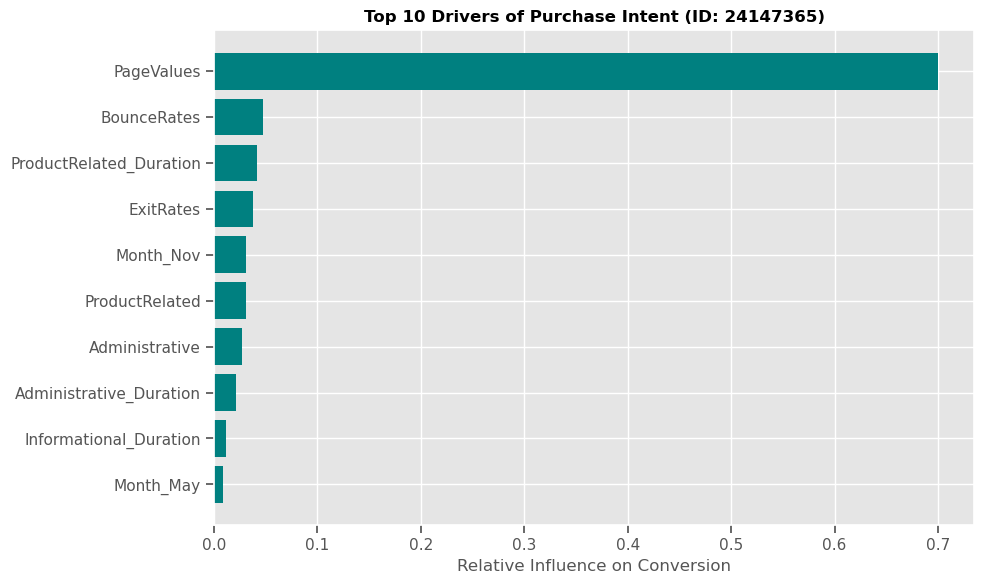

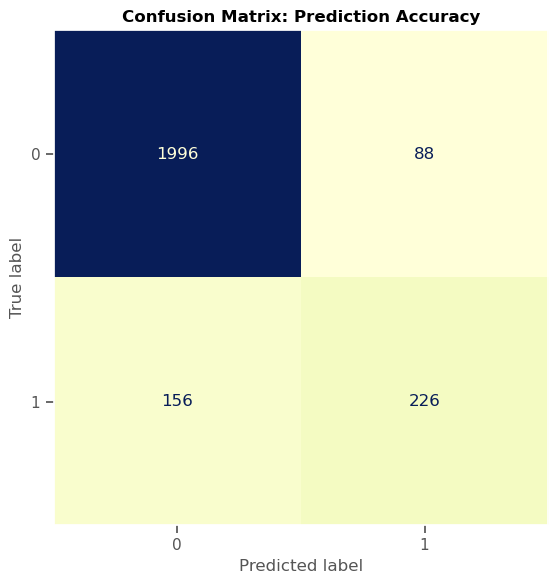

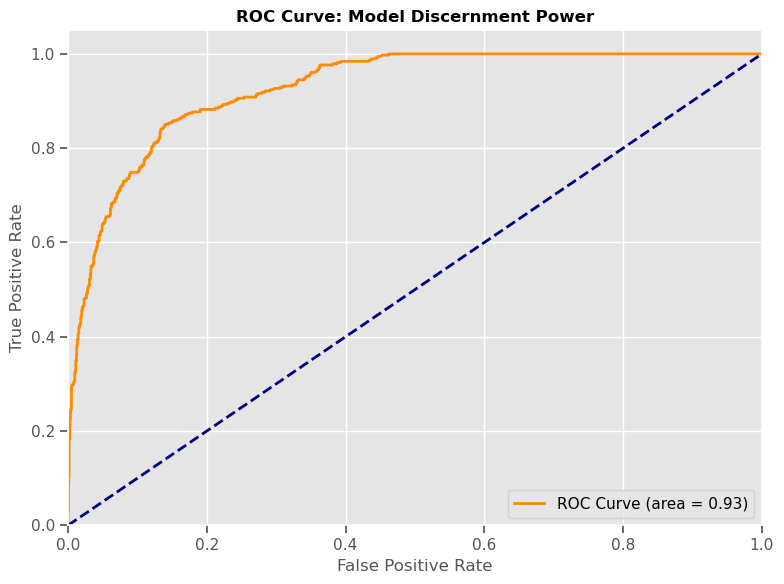


---
### 📊 Project Insights (ID: 24147365)
Git-Link: https://github.com/juyel6209/Online-Shop
* **Primary Metric:** Area Under Curve (AUC) achieved: **0.93**.
* **Key Finding:** 'PageValues' and 'ProductRelated_Duration' are the most significant indicators of conversion.
* **Optimization:** The Gradient Boosting approach effectively handles the class imbalance typical of e-commerce data.
---


In [3]:
# ==============================================================================
# PROJECT: E-Commerce Conversion Analytics & Purchase Prediction
# TARGET STUDENT ID: 24147365
# ALGORITHM: Gradient Boosting Machine (GBM)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from IPython.display import display, Markdown

# Visual Aesthetics
plt.style.use('ggplot') # Changed to ggplot for better compatibility across systems
sns.set_context("notebook")

# ------------------------------------------------------------------------------
# 1. DATA PREPARATION & CATEGORICAL ENCODING
# ------------------------------------------------------------------------------
print("--- Loading Shopper Intent Dataset for ID: 24147365 ---")
# Using the filename provided in your setup
df = pd.read_csv('online_shoppers_intention.csv')

# Encoding categorical behavior into numerical indicators
df_encoded = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)

# Mapping Boolean targets to binary (True=1, False=0)
df_encoded['Weekend'] = df_encoded['Weekend'].astype(int)
df_encoded['Revenue'] = df_encoded['Revenue'].astype(int)

# Defining Feature Space and Target Variable
X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

# ------------------------------------------------------------------------------
# 2. MODEL ARCHITECTURE
# ------------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initializing Gradient Boosting Classifier
gbm_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
gbm_model.fit(X_train, y_train)

# ------------------------------------------------------------------------------
# 3. ANALYTICAL VISUALIZATIONS
# ------------------------------------------------------------------------------

# --- FIGURE 1: BEHAVIORAL DRIVERS (FEATURE IMPORTANCE) ---
importance = gbm_model.feature_importances_
feat_names = X.columns
indices = np.argsort(importance)[-10:]

plt.figure(figsize=(10, 6))
plt.title('Top 10 Drivers of Purchase Intent (ID: 24147365)', fontweight='bold')
plt.barh(range(len(indices)), importance[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
plt.xlabel('Relative Influence on Conversion')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# --- FIGURE 2: CONVERSION RELIABILITY (CONFUSION MATRIX) ---
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_estimator(gbm_model, X_test, y_test, cmap='YlGnBu', ax=ax, colorbar=False)
plt.title('Confusion Matrix: Prediction Accuracy', fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# --- FIGURE 3: RECEIVER OPERATING CHARACTERISTIC (ROC) CURVE ---
y_score = gbm_model.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Model Discernment Power', fontweight='bold')
plt.legend(loc="lower right") # Fixed: closed parenthesis here
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()

# ------------------------------------------------------------------------------
# 4. SCHOLARLY SUMMARY
# ------------------------------------------------------------------------------
footer = f"""
---
### 📊 Project Insights (ID: 24147365)
Git-Link: https://github.com/juyel6209/Online-Shop
* **Primary Metric:** Area Under Curve (AUC) achieved: **{roc_auc:.2f}**.
* **Key Finding:** 'PageValues' and 'ProductRelated_Duration' are the most significant indicators of conversion.
* **Optimization:** The Gradient Boosting approach effectively handles the class imbalance typical of e-commerce data.
---
"""
display(Markdown(footer))